# PPMI Dataset Pre-processing

### Participant_Status_14Dec2025.csv

In [1]:
# Libraries
import pandas as pd

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load the dataframe
df = pd.read_csv("../../ppmi_pd/Participant_Status_14Dec2025.csv")

# Display info and head to understand columns
print(df.info())
print(df.head())

# Also print all column names to help with categorization
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PATNO               7905 non-null   int64  
 1   COHORT              7905 non-null   int64  
 2   COHORT_DEFINITION   7905 non-null   object 
 3   ENROLL_DATE         4509 non-null   object 
 4   ENROLL_STATUS       7905 non-null   object 
 5   STATUS_DATE         7904 non-null   object 
 6   SCREENEDAM          5816 non-null   float64
 7   ENROLL_AGE          4498 non-null   float64
 8   INEXPAGE            5820 non-null   object 
 9   AV133STDY           7058 non-null   float64
 10  TAUSTDY             7052 non-null   float64
 11  GAITSTDY            7052 non-null   float64
 12  PISTDY              7052 non-null   float64
 13  SV2ASTDY            7052 non-null   float64
 14  NXTAUSTDY           7052 non-null   float64
 15  DPPDSTDY            7052 non-null   float64
 16  DPPROS

In [3]:
# Load data dictionary and create column annotations
dd_df = pd.read_csv("../../ppmi_pd/Data___Databases/Data_Dictionary_-__Annotated__14Dec2025.csv")

# Filter for PATIENT_STATUS module first (primary source)
patient_status_dd = dd_df[dd_df['MOD_NAME'] == 'PATIENT_STATUS'].copy()

# Create a dictionary mapping column names (ITM_NAME) to descriptions (DSCR)
# Handle cases where ITM_NAME might be empty or spaces
column_annotations = {}
for idx, row in patient_status_dd.iterrows():
    itm_name = str(row['ITM_NAME']).strip()
    dscr = str(row['DSCR']).strip()
    
    # Skip empty ITM_NAME (these are module header rows)
    if itm_name and itm_name != 'nan' and itm_name != '':
        column_annotations[itm_name] = dscr if dscr != 'nan' else ''

# For any columns in df that are not found in PATIENT_STATUS, search across all modules
for col in df.columns:
    if col not in column_annotations:
        # Search for this column name across all modules
        col_rows = dd_df[dd_df['ITM_NAME'] == col]
        if not col_rows.empty:
            # Take the first match (or could prefer PATIENT_STATUS if multiple exist)
            dscr = str(col_rows.iloc[0]['DSCR']).strip()
            column_annotations[col] = dscr if dscr != 'nan' else ''

# Print column annotations for verification
print("Column Annotations Found:")
print("-" * 80)
for col in df.columns:
    if col in column_annotations and column_annotations[col]:
        print(f"{col:25s}: {column_annotations[col]}")
    else:
        print(f"{col:25s}: [Description not found in data dictionary]")
print("-" * 80)

# Store column annotations as a dictionary attribute for later use
df.attrs['column_descriptions'] = column_annotations


Column Annotations Found:
--------------------------------------------------------------------------------
PATNO                    : Participant ID
COHORT                   : Enrollment Cohort
COHORT_DEFINITION        : Decoded Value for COHORT
ENROLL_DATE              : Enrollment Date
ENROLL_STATUS            : Enrollment Status
STATUS_DATE              : Date Enrollment Status Occurred
SCREENEDAM               : PPMI Clinical Amendment Participant was Screened under
ENROLL_AGE               : Age at Enrollment
INEXPAGE                 : PPMI Clinical Inclusion/Criteria
AV133STDY                : Participant in PPMI Clinical Early Imaging Sub-Study
TAUSTDY                  : Participant in PPMI Clinical Tau Imaging Sub-Study
GAITSTDY                 : Participant in PPMI Clinical Gait Sub-Study
PISTDY                   : Participant in PPMI Clinical Prodromal Imaging Sub-Study
SV2ASTDY                 : Participant in PPMI Clinical SV2A PET Sub-Study
NXTAUSTDY                : Parti

In [4]:
print(df['COHORT_DEFINITION'].value_counts())

COHORT_DEFINITION
Prodromal              5400
Parkinson's Disease    1984
Healthy Control         440
SWEDD                    81
Name: count, dtype: int64


In [5]:
print(df['ENROLL_STATUS'].value_counts())

ENROLL_STATUS
Enrolled             3717
Screen failed        2760
Withdrew              541
Excluded              271
Screened              120
Declined              114
Complete              102
Pending                94
Withdraw Deceased      73
Baseline Withdraw      44
Screen Scheduled       38
Baseline               26
LP Eligible             4
Lost to follow-up       1
Name: count, dtype: int64


In [6]:
# Function to create the master key dataframe
def create_master_key(file_path):
    # 1. Load the raw status file
    df = pd.read_csv(file_path)

    # 2. Define the exact columns you requested
    columns_to_keep = [
        'PATNO', 
        'COHORT', 
        'COHORT_DEFINITION', 
        'ENROLL_DATE', 
        'ENROLL_STATUS',
        'STATUS_DATE',
        'ENROLL_AGE',
        'AV133STDY', 
        'TAUSTDY', 
        'GAITSTDY', 
        'PISTDY', 
        'SV2ASTDY', 
        'NXTAUSTDY', 
        'DPPDSTDY', 
        'DPPROSTDY', 
        'FD4STDY', 
        'DATELIG', 
        'PPMI_ONLINE_ENROLL', 
        'ENRLPINK1', # mutations linked to autosomal recessive early-onset PD. Rare, typically before age 40.
        'ENRLPRKN', # Parkin Mutation at Enrollment
        'ENRLSRDC', # PD without a known single genetic mutation.
        'ENRLNORM', # PD with normal sense of smell.
        'ENRLOTHGV', # Other Genetic Variant at Enrollment: Catches genetic variants not covered by the specific mutation columns
        'ENRLHPSM', # Reduced sense of smell (hyposmia) is a strong prodromal marker for PD
        'ENRLRBD', # A parasomnia where people act out dreams during REM sleep. Strong prodromal marker for PD. In PPMI
        'ENRLLRRK2', # the most common known genetic cause of PD
        'ENRLSNCA', # mutations are rare and often associated with early-onset and sometimes familial PD.
        'ENRLGBA' # mutations increase PD risk, and homozygous mutations cause Gaucher disease.
    ]

    # 3. Create the subset DataFrame
    master_df = df[columns_to_keep].copy()

    # ---------------------------------------------------------
    # FILTER 1: ENROLL_STATUS
    # ---------------------------------------------------------
    # Keeping only valid participants with longitudinal potential
    valid_statuses = [
        'Complete', 
        'Enrolled', 
        'Withdraw Deceased', 
        'Withdrew'
    ]
    master_df = master_df[master_df['ENROLL_STATUS'].isin(valid_statuses)]

    # ---------------------------------------------------------
    # FILTER 2: COHORT_DEFINITION
    # ---------------------------------------------------------
    # Mapping "PD" to the CSV value "Parkinson's Disease"
    # This automatically excludes SWEDD and other non-relevant cohorts
    valid_cohorts = [
        'Healthy Control', 
        "Parkinson's Disease", 
        'Prodromal'
    ]
    master_df = master_df[master_df['COHORT_DEFINITION'].isin(valid_cohorts)]

    # ---------------------------------------------------------
    # FILTER 3: ENROLL_DATE
    # ---------------------------------------------------------
    # Remove rows where Enrollment Date is Missing (Null)
    master_df = master_df.dropna(subset=['ENROLL_DATE'])

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Convert ENROLL_DATE to actual datetime objects for math calculations
    master_df['ENROLL_DATE'] = pd.to_datetime(master_df['ENROLL_DATE'], format='%m/%Y')    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    # ---------------------------------------------------------
    # FILTER 4: STATUS_DATE
    # ---------------------------------------------------------
    # Remove rows where Status Date is Missing (Null)
    master_df = master_df.dropna(subset=['STATUS_DATE'])

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Convert STATUS_DATE to actual datetime objects for math calculations
    master_df['STATUS_DATE'] = pd.to_datetime(master_df['STATUS_DATE'], format='%m/%Y')    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    # ---------------------------------------------------------
    # FILTER 5: PPMI Clinical + PPMI Remote (remove all PPMI Online only)
    # ---------------------------------------------------------
    # Remove rows where patient register for PPMI Online only
    # Logic: Keep participants who have ENROLL_DATE (PPMI Clinical) or are in PPMI Remote
    # Remove participants who are ONLY in PPMI Online (PPMI_ONLINE_ENROLL='YES' but no Clinical enrollment)
    # Since Filter 3 already requires ENROLL_DATE, we verify that participants with PPMI_ONLINE_ENROLL='YES' 
    # also have ENROLL_DATE (meaning they're in Clinical, not Online-only)
    # Participants in PPMI Online only would have PPMI_ONLINE_ENROLL='YES' and no ENROLL_DATE,
    # but those are already removed by Filter 3. However, we add this filter to be explicit
    # and to handle edge cases where ENROLL_DATE might be null for some reason.
    
    # Remove participants who are marked as PPMI Online enrollment but have no Clinical enrollment
    # (no ENROLL_DATE means they're not in Clinical)
    master_df = master_df[~((master_df['PPMI_ONLINE_ENROLL'] == 'YES') & (master_df['ENROLL_DATE'].isna()))]
    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    return master_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Participant_Status_14Dec2025.csv'
master_df = create_master_key(file_path)

# --- VERIFICATION ---
print(f"Final Master Key Shape: {master_df.shape}")
print("\nCohort Breakdown:")
print(master_df['COHORT_DEFINITION'].value_counts())
print("\nStatus Breakdown:")
print(master_df['ENROLL_STATUS'].value_counts())

Final Master Key Shape: (4369, 28)

Cohort Breakdown:
COHORT_DEFINITION
Prodromal              2546
Parkinson's Disease    1488
Healthy Control         335
Name: count, dtype: int64

Status Breakdown:
ENROLL_STATUS
Enrolled             3716
Withdrew              528
Withdraw Deceased      73
Complete               52
Name: count, dtype: int64


In [7]:
master_df.head(20)

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,ENROLL_AGE,AV133STDY,TAUSTDY,GAITSTDY,PISTDY,SV2ASTDY,NXTAUSTDY,DPPDSTDY,DPPROSTDY,FD4STDY,DATELIG,PPMI_ONLINE_ENROLL,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,2011-02-01,Withdrew,2024-10-01,69.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,2011-03-01,Enrolled,2021-09-01,65.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,2011-03-01,Withdrew,2024-10-01,67.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,2011-04-01,Enrolled,2022-01-01,56.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,2011-04-01,Enrolled,2022-01-01,59.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
5,3006,1,Parkinson's Disease,2011-05-01,Withdrew,2013-10-01,57.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
6,3007,1,Parkinson's Disease,2011-05-01,Withdrew,2011-06-01,64.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
7,3008,2,Healthy Control,2011-06-01,Withdrew,2024-04-01,81.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
8,3009,2,Healthy Control,2011-06-01,Enrolled,2021-05-01,83.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
9,3010,1,Parkinson's Disease,2011-06-01,Enrolled,2021-05-01,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0


## MOTOR__MDS-UPDRS

### Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv

In [8]:
def create_schwab_df(file_path):
    # 1. Load the raw Schwab & England file
    schwab_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'MSEADLG',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    schwab_df = schwab_df[columns_to_keep].copy()

    # Filter using your Master Key
    schwab_df = schwab_df[schwab_df['PATNO'].isin(master_df['PATNO'])]

    # 4. Filter out EVENT_IDs that are not relevant
    # REMOVE 'SC', 'ST', 'U01'
    events_to_remove = ['SC', 'ST', 'U01']
    
    # Keep rows where EVENT_ID is NOT in the remove list
    schwab_df = schwab_df[~schwab_df['EVENT_ID'].isin(events_to_remove)]

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Remove rows where MSEADLG is Missing (Null)
    schwab_df = schwab_df.dropna(subset=['MSEADLG'])
    print('Check for missing value:\n', schwab_df.isnull().sum())

    # Reset index for a clean dataframe
    schwab_df.reset_index(drop=True, inplace=True)


    # Convert INFODT to datetime
    schwab_df['INFODT'] = pd.to_datetime(schwab_df['INFODT'],format='%m/%Y')

    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    schwab_df = pd.merge(schwab_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    return schwab_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv'
schwab_df = create_schwab_df(file_path)

# Calculate Timeline
schwab_df['Months_Since_Enrollment'] = (
    (schwab_df['INFODT'] - schwab_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
).round().astype('Int64')

# Rename for consistency
schwab_df = schwab_df.rename(columns={'INFODT': 'VISIT_DATE', 'MSEADLG': 'Schwab_England_Score'})
schwab_df.shape

Check for missing value:
 REC_ID         0
PATNO          0
EVENT_ID       0
INFODT         0
MSEADLG        0
LAST_UPDATE    0
dtype: int64


(27418, 8)

In [9]:
schwab_df.head(10)

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,Schwab_England_Score,LAST_UPDATE,ENROLL_DATE,Months_Since_Enrollment
0,IA123379,3000,V17,2021-05-01,95.0,2021-06-01 00:00:00,2011-02-01,123
1,278744301,3001,BL,2011-03-01,95.0,2020-06-25 16:04:30,2011-03-01,0
2,IA123380,3001,R17,2021-11-01,65.0,2021-12-02 00:00:00,2011-03-01,128
3,IA123383,3001,R18,2022-09-01,70.0,2022-09-30 00:00:00,2011-03-01,138
4,IA318975,3001,R19,2023-08-01,70.0,2023-08-23 00:00:00,2011-03-01,149
5,294965201,3001,V01,2011-05-01,95.0,2020-06-25 16:04:33,2011-03-01,2
6,310817701,3001,V02,2011-08-01,95.0,2020-06-25 16:04:33,2011-03-01,5
7,322771101,3001,V03,2011-11-01,90.0,2020-06-25 16:04:33,2011-03-01,8
8,341438501,3001,V04,2012-03-01,95.0,2020-06-25 16:04:33,2011-03-01,12
9,362684001,3001,V05,2012-09-01,95.0,2020-06-25 16:04:33,2011-03-01,18


### Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv

In [10]:
neuro_qol_lower_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv')
neuro_qol_lower_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB25,NQMOB33,NQMOB31,NQMOB28,ORIG_ENTRY,LAST_UPDATE
0,736294201,3000,V15,NQOLLEFS,03/2019,5,5,5,5.0,5.0,5,5.0,5.0,04/2019,2020-06-25 16:02:24
1,IA132707,3000,V17,NQOLLEFS,05/2021,5,5,5,5.0,5.0,5,5.0,5.0,06/2021,2021-06-01 00:00:00
2,733239901,3001,V15,NQOLLEFS,03/2019,5,5,5,5.0,5.0,5,5.0,5.0,03/2019,2020-06-25 16:04:36
3,IA132708,3001,V17,NQOLLEFS,09/2021,4,5,3,4.0,4.0,3,4.0,4.0,01/2022,2022-01-06 00:00:00
4,IA132709,3001,V18,NQOLLEFS,07/2022,4,5,4,4.0,4.0,3,4.0,5.0,07/2022,2022-07-08 00:00:00


In [11]:
neuro_qol_lower_df.columns.tolist()

['REC_ID',
 'PATNO',
 'EVENT_ID',
 'PAG_NAME',
 'INFODT',
 'NQMOB37',
 'NQMOB30',
 'NQMOB26',
 'NQMOB32',
 'NQMOB25',
 'NQMOB33',
 'NQMOB31',
 'NQMOB28',
 'ORIG_ENTRY',
 'LAST_UPDATE']

In [12]:
neuro_qol_lower_df['EVENT_ID'].value_counts()

EVENT_ID
BL     3066
V04    2163
V06    1355
V08     683
V14     561
V15     549
V13     504
V10     433
V16     404
V12     396
V17     384
V18     326
V19     251
V20     186
V21      83
V22       7
R01       4
R06       3
R04       3
R14       1
Name: count, dtype: int64

In [13]:
def create_neuro_qol_lower_df(file_path):
    # 1. Load the raw Neuro-QOL Lower file
    neuro_qol_lower_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'NQMOB37',
        'NQMOB30',
        'NQMOB26',
        'NQMOB32',
        'NQMOB25',
        'NQMOB33',
        'NQMOB31',
        'NQMOB28',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    neuro_qol_lower_df = neuro_qol_lower_df[columns_to_keep].copy()

    # Filter using your Master Key
    neuro_qol_lower_df = neuro_qol_lower_df[neuro_qol_lower_df['PATNO'].isin(master_df['PATNO'])]

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Reset index for a clean dataframe
    neuro_qol_lower_df.reset_index(drop=True, inplace=True)

    # Convert INFODT to datetime
    neuro_qol_lower_df['INFODT'] = pd.to_datetime(neuro_qol_lower_df['INFODT'],format='%m/%Y')
    
    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    neuro_qol_lower_df = pd.merge(neuro_qol_lower_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    # 4. Calculate NQMOB_Total as the sum of the individual items
    neuro_qol_lower_df['NQMOB_Total'] = neuro_qol_lower_df[[
        'NQMOB37',
        'NQMOB30',
        'NQMOB26',
        'NQMOB32', 
        'NQMOB25',
        'NQMOB33',
        'NQMOB31',
        'NQMOB28'
    ]].sum(axis=1)

    # 5. Add the cohort information from the master key
    neuro_qol_lower_df = pd.merge(
        neuro_qol_lower_df,
        master_df[['PATNO', 'COHORT_DEFINITION']],
        on='PATNO',
        how='left'
    )

    # 6. Calculate Timeline
    neuro_qol_lower_df['Months_Since_Enrollment'] = (
        (neuro_qol_lower_df['INFODT'] - neuro_qol_lower_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    # Rename for consistency
    neuro_qol_lower_df = neuro_qol_lower_df.rename(columns={'INFODT': 'VISIT_DATE'})

    return neuro_qol_lower_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv'
neuro_qol_lower_df = create_neuro_qol_lower_df(file_path)

neuro_qol_lower_df.shape

(11241, 17)

In [14]:
neuro_qol_lower_df.head(10)

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB25,NQMOB33,NQMOB31,NQMOB28,LAST_UPDATE,ENROLL_DATE,NQMOB_Total,COHORT_DEFINITION,Months_Since_Enrollment
0,736294201,3000,V15,2019-03-01,5,5,5,5.0,5.0,5,5.0,5.0,2020-06-25 16:02:24,2011-02-01,40.0,Healthy Control,97
1,IA132707,3000,V17,2021-05-01,5,5,5,5.0,5.0,5,5.0,5.0,2021-06-01 00:00:00,2011-02-01,40.0,Healthy Control,123
2,733239901,3001,V15,2019-03-01,5,5,5,5.0,5.0,5,5.0,5.0,2020-06-25 16:04:36,2011-03-01,40.0,Parkinson's Disease,96
3,IA132708,3001,V17,2021-09-01,4,5,3,4.0,4.0,3,4.0,4.0,2022-01-06 00:00:00,2011-03-01,31.0,Parkinson's Disease,126
4,IA132709,3001,V18,2022-07-01,4,5,4,4.0,4.0,3,4.0,5.0,2022-07-08 00:00:00,2011-03-01,33.0,Parkinson's Disease,136
5,IA249073,3001,V19,2023-03-01,4,5,4,4.0,3.0,2,4.0,5.0,2023-03-29 00:00:00,2011-03-01,31.0,Parkinson's Disease,144
6,IA583158,3001,V20,2024-09-01,3,4,3,3.0,3.0,2,3.0,3.0,2024-09-25 00:00:00,2011-03-01,24.0,Parkinson's Disease,162
7,733825401,3002,V15,2019-03-01,4,4,3,2.0,2.0,3,2.0,2.0,2020-06-30 09:26:04,2011-03-01,22.0,Parkinson's Disease,96
8,IA132710,3002,V17,2021-09-01,3,2,2,2.0,2.0,1,1.0,3.0,2022-01-06 00:00:00,2011-03-01,16.0,Parkinson's Disease,126
9,IA132711,3002,V18,2022-03-01,4,2,3,1.0,1.0,1,1.0,1.0,2022-03-11 00:00:00,2011-03-01,14.0,Parkinson's Disease,132


**Higher NQMOB_Total means higher mobility.**

In [15]:
neuro_qol_lower_df['NQMOB_Total'].describe()

count    11241.000000
mean        37.631438
std          4.165932
min          8.000000
25%         37.000000
50%         39.000000
75%         40.000000
max         40.000000
Name: NQMOB_Total, dtype: float64

In [16]:
neuro_qol_lower_df[['PATNO','EVENT_ID','VISIT_DATE','NQMOB_Total','COHORT_DEFINITION']].head(10)

,PATNO,EVENT_ID,VISIT_DATE,NQMOB_Total,COHORT_DEFINITION
0,3000,V15,2019-03-01,40.0,Healthy Control
1,3000,V17,2021-05-01,40.0,Healthy Control
2,3001,V15,2019-03-01,40.0,Parkinson's Disease
3,3001,V17,2021-09-01,31.0,Parkinson's Disease
4,3001,V18,2022-07-01,33.0,Parkinson's Disease
5,3001,V19,2023-03-01,31.0,Parkinson's Disease
6,3001,V20,2024-09-01,24.0,Parkinson's Disease
7,3002,V15,2019-03-01,22.0,Parkinson's Disease
8,3002,V17,2021-09-01,16.0,Parkinson's Disease
9,3002,V18,2022-03-01,14.0,Parkinson's Disease


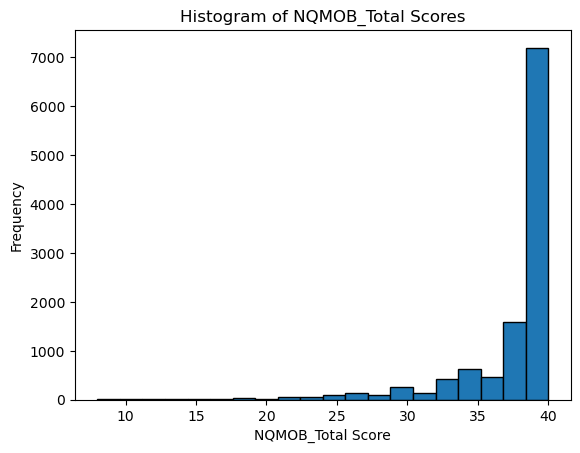

In [17]:
# Visualise the Neuro-QOL Lower Extremity DataFrame using the NQMOB_Total column
neuro_qol_lower_df['NQMOB_Total'].describe()

# Graph histogram of NQMOB_Total
import matplotlib.pyplot as plt
plt.hist(neuro_qol_lower_df['NQMOB_Total'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of NQMOB_Total Scores')
plt.xlabel('NQMOB_Total Score')
plt.ylabel('Frequency')
plt.show()

### Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv

In [18]:
neuro_qol_upper_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv')
neuro_qol_upper_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,ORIG_ENTRY,LAST_UPDATE
0,736294001,3000,V15,NQOLUEFS,03/2019,5,5.0,5.0,5.0,5,5,5,5.0,04/2019,2020-06-25 16:02:24
1,IA135021,3000,V17,NQOLUEFS,05/2021,5,5.0,5.0,5.0,5,5,5,5.0,06/2021,2021-06-01 00:00:00
2,733239701,3001,V15,NQOLUEFS,03/2019,4,5.0,5.0,5.0,4,4,5,5.0,03/2019,2020-06-25 16:04:36
3,IA135022,3001,V17,NQOLUEFS,09/2021,4,4.0,5.0,5.0,2,3,4,5.0,01/2022,2022-01-06 00:00:00
4,IA135023,3001,V18,NQOLUEFS,07/2022,4,4.0,4.0,4.0,2,3,4,5.0,07/2022,2022-07-08 00:00:00


In [19]:
def create_neuro_qol_upper_df(file_path):
    # 1. Load the raw Neuro-QOL Upper file
    neuro_qol_upper_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'NQUEX29',
        'NQUEX20',
        'NQUEX44',
        'NQUEX36',
        'NQUEX30',
        'NQUEX28',
        'NQUEX33',
        'NQUEX37',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    neuro_qol_upper_df = neuro_qol_upper_df[columns_to_keep].copy()

    # Filter using your Master Key
    neuro_qol_upper_df = neuro_qol_upper_df[neuro_qol_upper_df['PATNO'].isin(master_df['PATNO'])]

        # 4. Create another column for NQUEX_Total as the sum of the individual items
    neuro_qol_upper_df['NQUEX_Total'] = neuro_qol_upper_df[[
        'NQUEX29',
        'NQUEX20',
        'NQUEX44',
        'NQUEX36',
        'NQUEX30',
        'NQUEX28',
        'NQUEX33',
        'NQUEX37'
    ]].sum(axis=1)

        # 5. Add the cohort information from the master key
    neuro_qol_upper_df = pd.merge(
        neuro_qol_upper_df,
        master_df[['PATNO', 'COHORT_DEFINITION']],
        on='PATNO',
        how='left'
    )

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Reset index for a clean dataframe
    neuro_qol_upper_df.reset_index(drop=True, inplace=True)

    # Convert INFODT to datetime
    neuro_qol_upper_df['INFODT'] = pd.to_datetime(neuro_qol_upper_df['INFODT'],format='%m/%Y')
    
    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    neuro_qol_upper_df = pd.merge(neuro_qol_upper_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    # 6. Calculate Timeline
    neuro_qol_upper_df['Months_Since_Enrollment'] = (
        (neuro_qol_upper_df['INFODT'] - neuro_qol_upper_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')
    # Rename for consistency
    neuro_qol_upper_df = neuro_qol_upper_df.rename(columns={'INFODT': 'VISIT_DATE'})

    return neuro_qol_upper_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv'
neuro_qol_upper_df = create_neuro_qol_upper_df(file_path)

neuro_qol_upper_df.shape

(11237, 17)

**Higher NQUEX_Total means higher mobility.**

In [20]:
neuro_qol_upper_df['NQUEX_Total'].describe()

count    11237.000000
mean        38.778589
std          2.785674
min          8.000000
25%         39.000000
50%         40.000000
75%         40.000000
max         40.000000
Name: NQUEX_Total, dtype: float64

In [21]:
neuro_qol_upper_df[['PATNO','EVENT_ID','VISIT_DATE','NQUEX_Total','COHORT_DEFINITION']].head(10)

,PATNO,EVENT_ID,VISIT_DATE,NQUEX_Total,COHORT_DEFINITION
0,3000,V15,2019-03-01,40.0,Healthy Control
1,3000,V17,2021-05-01,40.0,Healthy Control
2,3001,V15,2019-03-01,37.0,Parkinson's Disease
3,3001,V17,2021-09-01,32.0,Parkinson's Disease
4,3001,V18,2022-07-01,30.0,Parkinson's Disease
5,3001,V19,2023-03-01,32.0,Parkinson's Disease
6,3001,V20,2024-09-01,28.0,Parkinson's Disease
7,3002,V15,2019-03-01,34.0,Parkinson's Disease
8,3002,V17,2021-09-01,30.0,Parkinson's Disease
9,3002,V18,2022-03-01,26.0,Parkinson's Disease


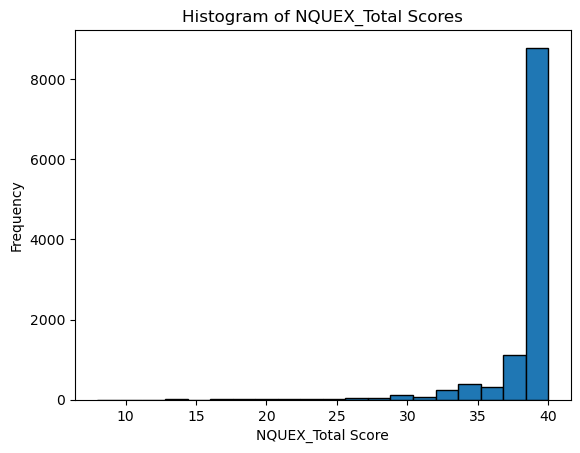

In [22]:
# Visualise the Neuro-QOL Upper Extremity DataFrame using the NQUEX_Total column
neuro_qol_upper_df['NQUEX_Total'].describe()

# Graph histogram of NQUEX_Total
import matplotlib.pyplot as plt
plt.hist(neuro_qol_upper_df['NQUEX_Total'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of NQUEX_Total Scores')
plt.xlabel('NQUEX_Total Score')
plt.ylabel('Frequency')
plt.show()

In [23]:
# Find the patient with the lowest NQUEX_Total score
neuro_qol_upper_df[neuro_qol_upper_df['NQUEX_Total']==8]

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,LAST_UPDATE,NQUEX_Total,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
4577,IA137256,101557,BL,2021-06-01,1,1.0,1.0,1.0,1,1,1,1.0,2021-07-01 00:00:00,8.0,Parkinson's Disease,2021-07-01,-1


In [24]:
# Check the patient NQUEX_Total score overtime
neuro_qol_upper_df[neuro_qol_upper_df['PATNO']==101557]

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,LAST_UPDATE,NQUEX_Total,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
4577,IA137256,101557,BL,2021-06-01,1,1.0,1.0,1.0,1,1,1,1.0,2021-07-01 00:00:00,8.0,Parkinson's Disease,2021-07-01,-1
4578,IA137257,101557,V04,2022-07-01,5,4.0,5.0,5.0,5,5,5,4.0,2022-07-14 00:00:00,38.0,Parkinson's Disease,2021-07-01,12
4579,IA288799,101557,V06,2023-06-01,5,5.0,5.0,5.0,5,5,5,5.0,2023-06-27 00:00:00,40.0,Parkinson's Disease,2021-07-01,23
4580,IA523363,101557,V08,2024-07-01,5,5.0,5.0,5.0,4,5,5,5.0,2024-07-02 00:00:00,39.0,Parkinson's Disease,2021-07-01,36
4581,IA774656,101557,V10,2025-07-01,5,3.0,5.0,5.0,4,5,5,5.0,2025-07-01 00:00:00,37.0,Parkinson's Disease,2021-07-01,48


### Participant_Motor_Function_Questionnaire_14Dec2025.csv

In [25]:
participant_motor_function_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv')
participant_motor_function_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,CMPLBY2,TRBUPCHR,WRTSMLR,VOICSFTR,POORBAL,FTSTUCK,LSSXPRSS,ARMLGSHK,TRBBUTTN,SHUFFLE,MVSLOW,TOLDPD,ORIG_ENTRY,LAST_UPDATE
0,IA71336,3000,V17,PQUEST,05/2021,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,06/2021,2021-06-01 00:00:00
1,IA71337,3001,V17,PQUEST,09/2021,1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,01/2022,2022-01-06 00:00:00
2,IA71338,3001,V18,PQUEST,07/2022,1,1.0,1.0,1.0,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,07/2022,2022-07-08 00:00:00
3,IA249051,3001,V19,PQUEST,03/2023,1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,03/2023,2023-03-29 00:00:00
4,IA583072,3001,V20,PQUEST,09/2024,1,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,09/2024,2024-09-25 00:00:00


In [26]:
participant_motor_function_df.shape

(10962, 19)

In [27]:
def create_participant_motor_function_df(file_path, master_df):
    # 1. Load the raw Participant Motor Function file
    pmfq_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    # Separation helps us know what to SUM vs what is METADATA
    symptom_cols = [
        'TRBUPCHR', # Trouble getting up from chair
        'WRTSMLR',  # Handwriting smaller
        'VOICSFTR', # Voice softer
        'POORBAL',  # Poor balance
        'FTSTUCK',  # Feet stuck to floor
        'LSSXPRSS', # Face less expressive
        'ARMLGSHK', # Arms/Legs shaking
        'TRBBUTTN', # Trouble buttoning buttons
        'SHUFFLE',  # Shuffling feet
        'MVSLOW'    # Moving slower
    ]
    
    meta_cols = [
        'REC_ID', 'PATNO', 'EVENT_ID', 'INFODT', 
        'CMPLBY2', # Completed by (1=Patient, 2=Both, 3=Caregiver)
        'TOLDPD'   # Told you have PD? (Yes/No) - Do not sum this!
    ]
    
    # 3. Create the subset DataFrame
    pmfq_df = pmfq_df[meta_cols + symptom_cols].copy()

    # 4. Filter using your Master Key
    pmfq_df = pmfq_df[pmfq_df['PATNO'].isin(master_df['PATNO'])]

    # ---------------------------------------------------------
    # SCORING LOGIC (The Fix)
    # ---------------------------------------------------------
    # Problem: Values are 0=No, 1=Yes, 2=Uncertain
    # If we sum blindly, "Uncertain" (2) counts double "Yes" (1). That is wrong.
    # Fix: Replace 2 with 0.5 (weighted as "Maybe") OR 0 (Conservative). 
    # We will use 0.5 to capture the signal without exaggeration.
    for col in symptom_cols:
        # Ensure numeric first (coerces errors to NaN)
        pmfq_df[col] = pd.to_numeric(pmfq_df[col], errors='coerce')
        pmfq_df[col] = pmfq_df[col].replace({2: 0.5})

    # 6. Create the Total Score
    # We sum ONLY the symptom columns, not the metadata
    pmfq_df['Self_Reported_Symptom_Count'] = pmfq_df[symptom_cols].sum(axis=1)

    # 7. Add Cohort Information
    pmfq_df = pd.merge(
        pmfq_df,
        master_df[['PATNO', 'COHORT_DEFINITION', 'ENROLL_DATE']],
        on='PATNO',
        how='left'
    )

    # ---------------------------------------------------------
    # CLEANUP & DATES
    # ---------------------------------------------------------
    # Convert INFODT to datetime
    pmfq_df['INFODT'] = pd.to_datetime(pmfq_df['INFODT'], errors='coerce', format='%m/%Y')

    # Calculate Timeline
    pmfq_df['Months_Since_Enrollment'] = (
        (pmfq_df['INFODT'] - pmfq_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    # Rename for consistency
    pmfq_df = pmfq_df.rename(columns={'INFODT': 'VISIT_DATE'})
    
    # Reset index
    pmfq_df.reset_index(drop=True, inplace=True)

    return pmfq_df

# --- EXECUTION ---
# Make sure the path points to the MOTOR FUNCTION file, not Neuro-QoL
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv'

# Ensure master_df exists from previous steps
# master_df = create_master_key(...) 

participant_motor_func_df = create_participant_motor_function_df(file_path, master_df)

# Check results
print(f"Shape: {participant_motor_func_df.shape}")
print(participant_motor_func_df[['PATNO', 'VISIT_DATE', 'Self_Reported_Symptom_Count']].head())
participant_motor_func_df.head(10)

Shape: (10841, 20)
   PATNO VISIT_DATE  Self_Reported_Symptom_Count
0   3000 2021-05-01                          0.0
1   3001 2021-09-01                          8.0
2   3001 2022-07-01                          8.5
3   3001 2023-03-01                          8.0
4   3001 2024-09-01                          9.0


,REC_ID,PATNO,EVENT_ID,VISIT_DATE,CMPLBY2,TOLDPD,TRBUPCHR,WRTSMLR,VOICSFTR,POORBAL,FTSTUCK,LSSXPRSS,ARMLGSHK,TRBBUTTN,SHUFFLE,MVSLOW,Self_Reported_Symptom_Count,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
0,IA71336,3000,V17,2021-05-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Healthy Control,2011-02-01,123
1,IA71337,3001,V17,2021-09-01,1,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,8.0,Parkinson's Disease,2011-03-01,126
2,IA71338,3001,V18,2022-07-01,1,1.0,1.0,1.0,1.0,0.5,1.0,0.0,1.0,1.0,1.0,1.0,8.5,Parkinson's Disease,2011-03-01,136
3,IA249051,3001,V19,2023-03-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,8.0,Parkinson's Disease,2011-03-01,144
4,IA583072,3001,V20,2024-09-01,1,1.0,1.0,1.0,1.0,1.0,0.5,0.5,1.0,1.0,1.0,1.0,9.0,Parkinson's Disease,2011-03-01,162
5,IA71339,3002,V17,2021-09-01,1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,8.0,Parkinson's Disease,2011-03-01,126
6,IA71340,3002,V18,2022-03-01,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,9.0,Parkinson's Disease,2011-03-01,132
7,IA71341,3003,V18,2022-04-01,1,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,7.0,Parkinson's Disease,2011-04-01,132
8,IA264831,3003,V19,2023-05-01,1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0,Parkinson's Disease,2011-04-01,145
9,IA485702,3003,V20,2024-05-01,1,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,Parkinson's Disease,2011-04-01,157


**Self_Reported_Symptom_Count**

* 0 = No symptoms reported (Perfectly healthy).

* 10 = All symptoms reported (Severe issues).

In [28]:
# describe the Self_Reported_Symptom_Count column
participant_motor_func_df['Self_Reported_Symptom_Count'].describe()

count    10841.000000
mean         2.248086
std          2.652542
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         10.000000
Name: Self_Reported_Symptom_Count, dtype: float64

### MDS-UPDRS_Part_III_14Dec2025.csv

In [29]:
mds_updrs_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')
mds_updrs_part_3_df.head(5)

/var/folders/62/zjqy8smd44n_h59ql8q_nhy80000gn/T/ipykernel_1110/361327882.py:1: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  mds_updrs_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,PDMEDYN,DBSYN,ONOFFORDER,OFFEXAM,OFFNORSN,DBSOFFYN,DBSOFFTM,ONEXAM,ONNORSN,HIFUYN,DBSONYN,DBSONTM,PDMEDDT,PDMEDTM,EXAMDT,EXAMTM,NP3SPCH,NP3FACXP,NP3RIGN,NP3RIGRU,NP3RIGLU,NP3RIGRL,NP3RIGLL,NP3FTAPR,NP3FTAPL,NP3HMOVR,NP3HMOVL,NP3PRSPR,NP3PRSPL,NP3TTAPR,NP3TTAPL,NP3LGAGR,NP3LGAGL,NP3RISNG,NP3GAIT,NP3FRZGT,NP3PSTBL,NP3POSTR,NP3BRADY,NP3PTRMR,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,ORIG_ENTRY,LAST_UPDATE
0,272451901,3000,BL,NUPDRS3,02/2011,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2011,13:17:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2011,2020-06-25 16:02:19
1,338703101,3000,V04,NUPDRS3,03/2012,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2012,13:47:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,03/2012,2020-06-25 16:02:22
2,385009801,3000,V06,NUPDRS3,02/2013,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2013,12:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2013,2020-06-25 16:02:22
3,437131401,3000,V08,NUPDRS3,03/2014,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2014,13:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,05/2014,2020-06-25 16:02:22
4,512469901,3000,V10,NUPDRS3,03/2015,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2015,11:43:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,NaN,0.0,03/2015,2020-06-25 16:02:23
